In [ ]:
# Knapsack project:
# QFT-based arithmetic + Grover-style amplitude amplification
#
# Simplified proof-of-concept inspired by:
# "A quantum algorithm for solving 0-1 Knapsack problems"
#
# Small example:
# 3 items
# weights = [2, 1, 1]
# profits = [3, 2, 2]
# capacity = 3
#
# Good solutions with profit >= 4 and weight <= 3 are:
# 011, 101, 110
#
# Optimal solutions are:
# 101 and 110   (profit = 5)

In [13]:
# import libraries

import numpy as np
from numpy import pi
import matplotlib.pyplot as plt


# Qiskit libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.synthesis.qft import synth_qft_full
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler

# visualization
from qiskit.visualization import plot_histogram

In [2]:
# problem setup

weights = [2, 1, 1]
profits = [3, 2, 2]
capacity = 3
threshold = 4

n_items = len(weights)

# number of qubits for weight and profit registers
# max total weight = 2 + 1 + 1 = 4  -> need 3 qubits
# max total profit = 3 + 2 + 2 = 7 -> need 3 qubits
n_weight = 3
n_profit = 3

In [3]:
# helper function:
# QFT-based addition of a classical constant 'a' on a quantum register
#
# This function assumes the target register is already in the Fourier basis.
# It applies phase rotations corresponding to adding a to the register.

def add_const_in_fourier_basis(qc, target_reg, a):
    n = len(target_reg)
    
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.p(angle, target_reg[j])

In [4]:
# helper function:
# controlled QFT-based addition of a classical constant 'a'
#
# If the control qubit is |1>, then add 'a' to the target register
# while the target register is in the Fourier basis.

def controlled_add_const_in_fourier_basis(qc, control_qubit, target_reg, a):
    n = len(target_reg)
    
    for j in range(n):
        angle = 2 * pi * a / (2 ** (j + 1))
        qc.cp(angle, control_qubit, target_reg[j])

In [5]:
# helper function:
# build the diffusion operator on the path register only
#
# This is the standard Grover diffuser:
# H -> X -> multi-controlled Z -> X -> H

def diffuser(n):
    qc = QuantumCircuit(n)

    # Apply H to all qubits
    for q in range(n):
        qc.h(q)

    # Apply X to all qubits
    for q in range(n):
        qc.x(q)

    # multi-controlled Z
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Apply X to all qubits
    for q in range(n):
        qc.x(q)

    # Apply H to all qubits
    for q in range(n):
        qc.h(q)

    return qc

In [6]:
# helper function:
# oracle that marks the "good" path states
#
# For this tiny example, we mark:
# 011, 101, 110
#
# This is a simplified oracle on the path register.

def phase_oracle_good_states():
    qc = QuantumCircuit(n_items)

    # mark |011>
    qc.x(2)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x(2)

    # mark |101>
    qc.x(1)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x(1)

    # mark |110>
    qc.x(0)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x(0)

    return qc

In [7]:
# build the main circuit
#
# registers:
# path   -> item choices x1, x2, x3
# weight -> total selected weight
# profit -> total selected profit
# c_path -> measurement bits for the path register

path = QuantumRegister(n_items, 'x')
weight = QuantumRegister(n_weight, 'w')
profit = QuantumRegister(n_profit, 'p')
c_path = ClassicalRegister(n_items, 'c')

qc = QuantumCircuit(path, weight, profit, c_path)

In [8]:
# Step 1:
# create equal superposition over all item choices

for q in range(n_items):
    qc.h(path[q])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "x"), index=0>, <Qubit register=(3, "x"), index=1>, <Qubit register=(3, "x"), index=2>, <Qubit register=(3, "w"), index=0>, <Qubit register=(3, "w"), index=1>, <Qubit register=(3, "w"), index=2>, <Qubit register=(3, "p"), index=0>, <Qubit register=(3, "p"), index=1>, <Qubit register=(3, "p"), index=2>), clbits=())

In [15]:
# Step 2:
# compute total weight into the weight register using QFT-based addition
#
# for each item qubit x_m:
# if x_m = 1, add weights[m] to the weight register
qc.append(synth_qft_full(n_weight, do_swaps=False), weight)


for m in range(n_items):
    controlled_add_const_in_fourier_basis(qc, path[m], weight, weights[m])

qc.append(synth_qft_full(n_weight, do_swaps=False).inverse(), weight)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "x"), index=0>, <Qubit register=(3, "x"), index=1>, <Qubit register=(3, "x"), index=2>, <Qubit register=(3, "w"), index=0>, <Qubit register=(3, "w"), index=1>, <Qubit register=(3, "w"), index=2>, <Qubit register=(3, "p"), index=0>, <Qubit register=(3, "p"), index=1>, <Qubit register=(3, "p"), index=2>), clbits=())

In [16]:
# Step 3:
# compute total profit into the profit register using QFT-based addition
#
# for each item qubit x_m:
# if x_m = 1, add profits[m] to the profit register

qc.append(synth_qft_full(n_profit, do_swaps=False), profit)

for m in range(n_items):
    controlled_add_const_in_fourier_basis(qc, path[m], profit, profits[m])

qc.append(synth_qft_full(n_profit, do_swaps=False).inverse(), profit)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "x"), index=0>, <Qubit register=(3, "x"), index=1>, <Qubit register=(3, "x"), index=2>, <Qubit register=(3, "w"), index=0>, <Qubit register=(3, "w"), index=1>, <Qubit register=(3, "w"), index=2>, <Qubit register=(3, "p"), index=0>, <Qubit register=(3, "p"), index=1>, <Qubit register=(3, "p"), index=2>), clbits=())

In [17]:
# Step 4:
# apply the simplified phase oracle on the path register
#
# In a full implementation, the oracle would examine the weight and profit
# registers and mark states satisfying:
#   weight <= capacity
#   profit >= threshold
#
# For this project, we already know which path states are "good",
# so we mark them directly on the path register.

oracle = phase_oracle_good_states()
qc.compose(oracle, qubits=path, inplace=True)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "x"), index=0>, <Qubit register=(3, "x"), index=1>, <Qubit register=(3, "x"), index=2>, <Qubit register=(3, "w"), index=0>, <Qubit register=(3, "w"), index=1>, <Qubit register=(3, "w"), index=2>, <Qubit register=(3, "p"), index=0>, <Qubit register=(3, "p"), index=1>, <Qubit register=(3, "p"), index=2>), clbits=())

In [18]:
# Step 5:
# uncompute the arithmetic registers
#
# This is important in Grover-like routines.
# After the oracle, we should clean up helper information and return
# ancilla/work registers to their original state before the diffuser.

qc.append(synth_qft_full(n_profit, do_swaps=False), profit)


for m in reversed(range(n_items)):
    controlled_add_const_in_fourier_basis(qc, path[m], profit, -profits[m])

qc.append(synth_qft_full(n_profit, do_swaps=False).inverse(), profit)


qc.barrier()

qc.append(synth_qft_full(n_weight, do_swaps=False), weight)

for m in reversed(range(n_items)):
    controlled_add_const_in_fourier_basis(qc, path[m], weight, -weights[m])

qc.append(synth_qft_full(n_weight, do_swaps=False).inverse(), weight)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "x"), index=0>, <Qubit register=(3, "x"), index=1>, <Qubit register=(3, "x"), index=2>, <Qubit register=(3, "w"), index=0>, <Qubit register=(3, "w"), index=1>, <Qubit register=(3, "w"), index=2>, <Qubit register=(3, "p"), index=0>, <Qubit register=(3, "p"), index=1>, <Qubit register=(3, "p"), index=2>), clbits=())

In [19]:
# Step 6:
# apply the Grover diffuser on the path register

diff = diffuser(n_items)
qc.compose(diff, qubits=path, inplace=True)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=9, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "x"), index=0>, <Qubit register=(3, "x"), index=1>, <Qubit register=(3, "x"), index=2>, <Qubit register=(3, "w"), index=0>, <Qubit register=(3, "w"), index=1>, <Qubit register=(3, "w"), index=2>, <Qubit register=(3, "p"), index=0>, <Qubit register=(3, "p"), index=1>, <Qubit register=(3, "p"), index=2>), clbits=())

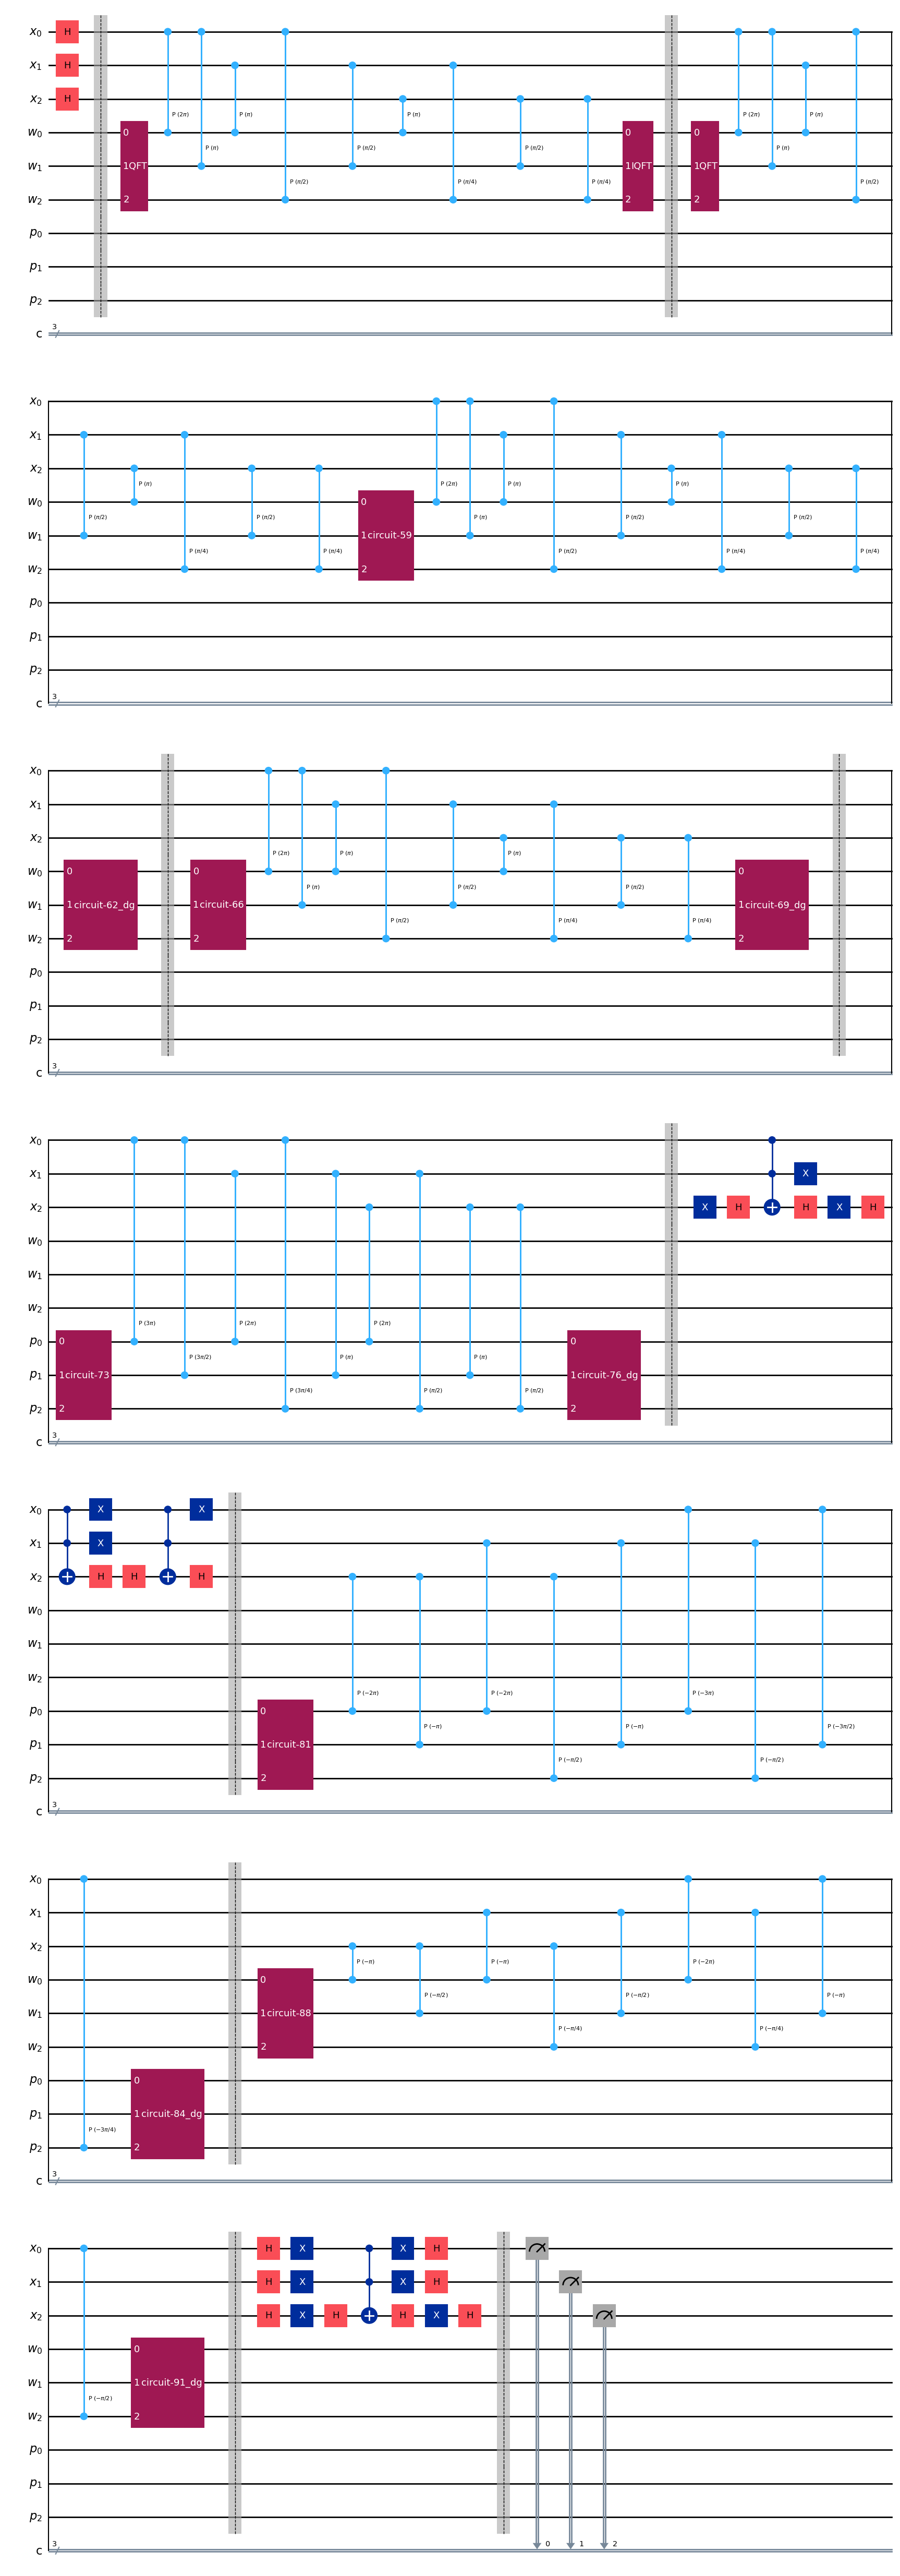

In [20]:
# Step 7:
# measure only the path register

qc.measure(path, c_path)

# draw the circuit
qc.draw('mpl')

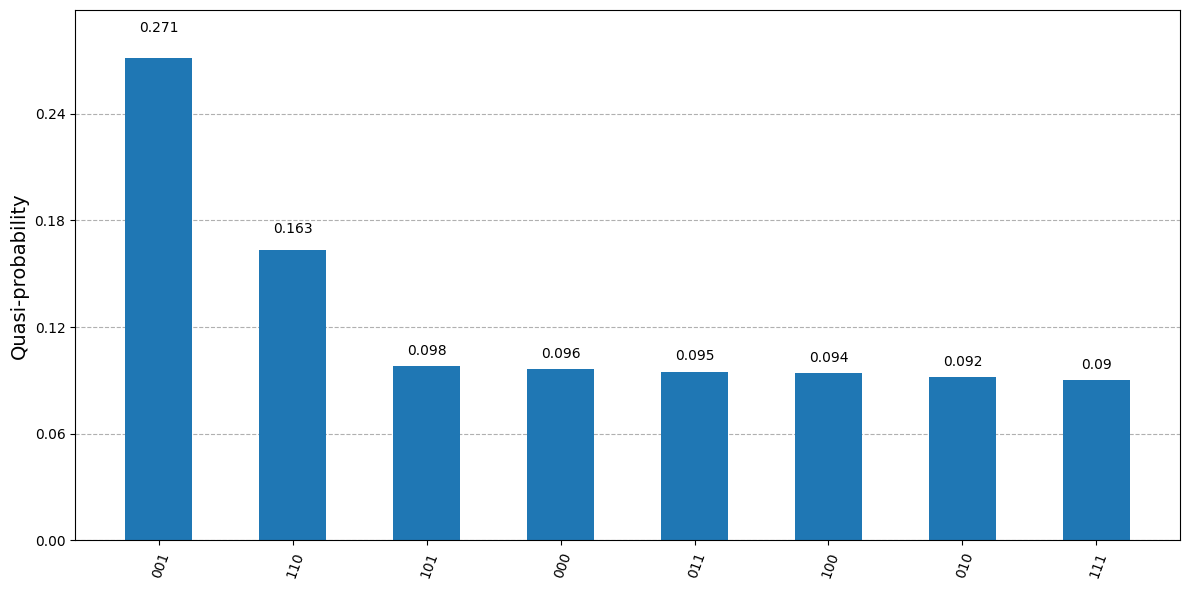

In [24]:
# Execute simulations

sampler = AerSampler()
job_sim = sampler.run([qc], shots=4096)

quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()

plot_histogram(
    quasi_dists,
    sort='value_desc',
    figsize=(12, 6),
    bar_labels=True
)

In [22]:
# Interpret results

sorted_results = sorted(quasi_dists.items(), key=lambda x: x[1], reverse=True)
sorted_results

[('001', 0.2841796875),
 ('110', 0.174560546875),
 ('000', 0.0966796875),
 ('011', 0.095458984375),
 ('101', 0.08935546875),
 ('111', 0.087646484375),
 ('010', 0.08740234375),
 ('100', 0.084716796875)]

In [23]:
# Classical check:
# print all subsets with their weights and profits

print("bitstring   weight   profit   feasible")

for x in range(2**n_items):
    bits = format(x, f'0{n_items}b')
    
    total_w = 0
    total_p = 0
    
    for i, bit in enumerate(bits[::-1]):   # reverse because Qiskit uses little-endian qubit ordering
        if bit == '1':
            total_w += weights[i]
            total_p += profits[i]
    
    feasible = (total_w <= capacity)
    print(f"{bits:>7}   {total_w:>6}   {total_p:>6}   {feasible}")

bitstring   weight   profit   feasible
    000        0        0   True
    001        2        3   True
    010        1        2   True
    011        3        5   True
    100        1        2   True
    101        3        5   True
    110        2        4   True
    111        4        7   False
